# 🔵 K-Means Clustering
## From objective → derivation → matrix form → NumPy → SciPy → PyTorch/CUDA

> **Notebook contract:** derive it, understand it, resolve the ambiguities, express the structure, implement it elegantly, use the scientific library, move the same mathematics to the GPU, visualize it, and test what should remain invariant.

The central optimization problem is deceptively small:

$$
\boxed{
J(Z,M)=\sum_{i=1}^{N}\sum_{k=1}^{K} z_{ik}\|x_i-\mu_k\|_2^2
}
$$

Everything in Lloyd's K-Means algorithm follows from alternating between two exact conditional minimizations:

$$
\boxed{
\text{nearest centroid}
\quad\longleftrightarrow\quad
\text{mean of assigned points}
}
$$

This notebook keeps the mathematics and the implementation deliberately aligned. The same dataset and the same initial centroids are used for NumPy, SciPy, and PyTorch so that the computational substrate changes while the mathematical problem does not.


## 1. Conceptual landscape

Suppose we want to represent $N$ observations using only $K$ prototype vectors. Each observation chooses one prototype, and we pay a squared-error penalty for the mismatch.

There are therefore two coupled unknowns:

- **assignment:** which centroid represents each observation;
- **representation:** where each centroid should be located.

If the centroid locations are known, the best assignment is obvious: choose the nearest centroid.

If the assignments are known, the best centroid location is also determined: use the mean of the points assigned to that cluster.

K-Means alternates these two operations until the assignments stop changing.

### 🟢 What K-Means is really exploiting

Squared Euclidean distance has a special property:

$$
\boxed{
\text{the arithmetic mean uniquely minimizes the sum of squared distances}
}
$$

That fact is not an implementation detail. It is the mathematical reason the centroid update is a mean.


## 2. Objects, notation, dimensions, and conventions

We use the **row-observation convention** throughout:

$$
X=
\begin{bmatrix}
x_1^T\\
x_2^T\\
\vdots\\
x_N^T
\end{bmatrix}
\in\mathbb R^{N\times D},
\qquad
x_i\in\mathbb R^D.
$$

The assignment matrix is

$$
Z\in\{0,1\}^{N\times K},
$$

with one-hot rows:

$$
\sum_{k=1}^{K}z_{ik}=1
\qquad\forall i.
$$

The centroid matrix is

$$
M=
\begin{bmatrix}
\mu_1^T\\
\mu_2^T\\
\vdots\\
\mu_K^T
\end{bmatrix}
\in\mathbb R^{K\times D}.
$$

| Symbol | Meaning | Shape / type | Role |
|---|---|---:|---|
| $x_i$ | observation $i$ | $\mathbb R^D$ | fixed data |
| $X$ | all observations as rows | $N\times D$ | fixed data |
| $z_{ik}$ | assignment indicator | $\{0,1\}$ | optimized when $M$ is fixed |
| $Z$ | all assignments | $N\times K$ | optimized when $M$ is fixed |
| $\mu_k$ | centroid of cluster $k$ | $\mathbb R^D$ | optimized when $Z$ is fixed |
| $M$ | all centroids as rows | $K\times D$ | optimized when $Z$ is fixed |

### Clarification checkpoint — mathematical vector vs stored row

Mathematically, $x_i$ is naturally treated as a column vector in $\mathbb R^D$. In the array $X$, the transpose $x_i^T$ occupies row $i$.

That convention matters. Because observations are rows,

$$
Z^TX:(K,N)(N,D)=(K,D)
$$

is the cluster-sum operation. If observations were stored as columns in $X_{\text{col}}\in\mathbb R^{D\times N}$, the analogous operation would be $X_{\text{col}}Z$.


## 3. Assumptions and what is *not* assumed

### Mathematical assumptions used by the canonical derivation

1. $K$ is fixed.
2. Each observation belongs to exactly one cluster.
3. The loss is **squared Euclidean distance**.
4. Every cluster is non-empty during the centroid update.

### Favorable geometry — not mathematical requirements

K-Means works especially naturally when clusters are roughly compact, separated, and similar in scale. It can behave poorly for strongly non-spherical clusters, highly unequal densities, severe outliers, or badly scaled features.

### 🟡 Implementation policy

Initialization, empty-cluster recovery, stopping tolerances, and K-Means++ are implementation choices or extensions. They are not part of the minimal derivation below.


## 4. Objective function

K-Means minimizes

$$
\boxed{
J(Z,M)
=
\sum_{i=1}^{N}
\sum_{k=1}^{K}
z_{ik}\|x_i-\mu_k\|_2^2
}
$$

subject to

$$
z_{ik}\in\{0,1\},
\qquad
\sum_{k=1}^{K}z_{ik}=1.
$$

For a fixed observation $x_i$, exactly one element of its assignment row $z_i$ is 1. Thus

$$
\sum_{k=1}^{K}z_{ik}\|x_i-\mu_k\|^2
$$

contains $K$ candidate distances, but after the assignment is chosen the one-hot row acts as a switch and retains only one of them.

### Clarification checkpoint — is $Z$ already filtering?

Only **after $Z$ has been chosen**. During the assignment step, the centroids are fixed but the assignment row $z_i$ is still a decision variable.

The logical order is

$$
\boxed{
\text{compare distances}
\rightarrow
\arg\min
\rightarrow
\text{construct }z_i
\rightarrow
z_i\text{ becomes the filter}
}
$$


## 5. Equivalent objective and alternating minimization

For fixed centroids, the best possible assignment for observation $x_i$ is the nearest centroid. Therefore the explicit one-hot formulation can be written equivalently as

$$
\boxed{
\min_{\mu_1,\ldots,\mu_K}
\sum_{i=1}^{N}
\min_k\|x_i-\mu_k\|^2
}
$$

because the inner minimum already incorporates the optimal one-hot choice.

Joint optimization over $Z$ and $M$ is difficult, but each conditional problem is easy:

$$
M^{(0)}
\rightarrow
Z^{(1)}
\rightarrow
M^{(1)}
\rightarrow
Z^{(2)}
\rightarrow
M^{(2)}
\rightarrow\cdots
$$

with

$$
Z^{(t+1)}=\arg\min_Z J(Z,M^{(t)})
$$

and

$$
M^{(t+1)}=\arg\min_M J(Z^{(t+1)},M).
$$

| Step | Fixed | Optimized |
|---|---|---|
| Assignment | $M$ | $Z$ |
| Centroid update | $Z$ | $M$ |

### Clarification checkpoint — what is fixed and what varies?

The index $k$ can be fixed while the vector $\mu_k$ remains variable. “Consider cluster $k$” means *select one label*. It does **not** mean its centroid coordinates have already been determined.


# 6. Assignment step — fixed centroids, optimize $Z$

For one observation $x_i$, define

$$
J_i(z_i,M)=\sum_{k=1}^{K}z_{ik}\|x_i-\mu_k\|^2.
$$

Because $z_i$ must contain exactly one 1, minimizing $J_i$ means placing that 1 at the smallest candidate distance:

$$
\boxed{
c_i=\arg\min_k\|x_i-\mu_k\|_2^2
}
$$

and equivalently

$$
z_{ik}=\mathbf 1[k=c_i].
$$

The derivation is written for one $x_i$, but the complete update performs the same independent choice for all $N$ observations:

$$
\min_Z J(Z,M)
=
\sum_{i=1}^{N}\min_{z_i}J_i(z_i,M).
$$

### Clarification checkpoint — one observation or the whole dataset?

The optimization separates across rows of $Z$. Each row is solved independently, so all $N$ nearest-centroid decisions can be computed simultaneously.


## 6.1 Pairwise squared distances in matrix form

For every pair $(i,k)$,

$$
\|x_i-\mu_k\|^2
=
x_i^Tx_i+\mu_k^T\mu_k-2x_i^T\mu_k.
$$

Define

$$
a_i=\|x_i\|^2,
\qquad
b_k=\|\mu_k\|^2.
$$

Then the complete distance matrix $D\in\mathbb R^{N\times K}$ is

$$
\boxed{
D
=
a\mathbf 1_K^T
+
\mathbf 1_N b^T
-
2XM^T
}
$$

with

$$
D_{ik}=\|x_i-\mu_k\|^2.
$$

Dimensions:

$$
XM^T:(N,D)(D,K)=(N,K).
$$

The assignment vector is therefore simply

$$
\boxed{
c=\operatorname{argmin}_{\text{columns}}D.
}
$$

### What does $XM^T$ mean?

Entry $(i,k)$ is the inner product $x_i^T\mu_k$. Thus one matrix multiplication computes **every observation–centroid cross term simultaneously**.


## 6.2 A complete exact running example

Use three observations in two dimensions:

$$
X=
\begin{bmatrix}
4&6\\
6&8\\
10&3
\end{bmatrix}
$$

and begin with centroids

$$
M^{(0)}=
\begin{bmatrix}
4&6\\
10&3
\end{bmatrix}.
$$

The squared-distance matrix is

$$
D=
\begin{bmatrix}
0&45\\
8&41\\
45&0
\end{bmatrix}.
$$

Taking the minimum across each row gives

$$
c=
\begin{bmatrix}
1\\1\\2
\end{bmatrix}
$$

and therefore

$$
Z=
\begin{bmatrix}
1&0\\
1&0\\
0&1
\end{bmatrix}.
$$

This same tiny example will carry through the centroid derivation, so we can see the entire Lloyd step without changing notation or data.


In [1]:
import numpy as np

X_small = np.array([
    [4.0, 6.0],
    [6.0, 8.0],
    [10.0, 3.0],
])

M0_small = np.array([
    [4.0, 6.0],
    [10.0, 3.0],
])

D_small = (
    (X_small * X_small).sum(axis=1)[:, None]
    + (M0_small * M0_small).sum(axis=1)[None, :]
    - 2 * X_small @ M0_small.T
)

labels_small = D_small.argmin(axis=1)
Z_small = np.eye(len(M0_small), dtype=int)[labels_small]

print("Squared-distance matrix D =")
print(D_small)
print("\nlabels =", labels_small)
print("\nZ =")
print(Z_small)


Squared-distance matrix D =
[[ 0. 45.]
 [ 8. 41.]
 [45.  0.]]

labels = [0 0 1]

Z =
[[1 0]
 [1 0]
 [0 1]]


# 7. Centroid update — fixed $Z$, optimize $M$

Now hold the assignments fixed and consider one fixed cluster label $k$:

$$
J_k(\mu_k)
=
\sum_{i=1}^{N}z_{ik}\|x_i-\mu_k\|^2.
$$

We seek

$$
\boxed{
\mu_k^*=\arg\min_{\mu_k}J_k(\mu_k).
}
$$

### Clarification checkpoint — if $k$ is fixed, why is $\mu_k$ changing?

Because $k$ is only an **index**. We have chosen which cluster we are discussing; we have not yet chosen the coordinates of that cluster's centroid.

$$
k=\text{fixed label},
\qquad
\mu_k=\text{free vector in }\mathbb R^D.
$$


## 7.1 Expanded derivation — expose every term

Start with

$$
J_k(\mu_k)=\sum_i z_{ik}\|x_i-\mu_k\|^2.
$$

Expand the squared norm:

$$
\|x_i-\mu_k\|^2
=(x_i-\mu_k)^T(x_i-\mu_k)
$$

$$
=x_i^Tx_i-2x_i^T\mu_k+\mu_k^T\mu_k.
$$

Therefore

$$
J_k
=
\sum_i z_{ik}
\left(
x_i^Tx_i-2x_i^T\mu_k+\mu_k^T\mu_k
\right).
$$

Differentiate with respect to the vector $\mu_k$:

$$
\nabla_{\mu_k}(x_i^Tx_i)=0,
$$

$$
\nabla_{\mu_k}(-2x_i^T\mu_k)=-2x_i,
$$

and

$$
\nabla_{\mu_k}(\mu_k^T\mu_k)=2\mu_k.
$$

Hence

$$
\nabla_{\mu_k}J_k
=2\sum_i z_{ik}(\mu_k-x_i).
$$

At the minimum,

$$
2\sum_i z_{ik}(\mu_k-x_i)=0.
$$

Therefore

$$
\mu_k\sum_i z_{ik}=\sum_i z_{ik}x_i,
$$

so

$$
\boxed{
\mu_k^*
=
\frac{\sum_i z_{ik}x_i}{\sum_i z_{ik}}.
}
$$

If $N_k=\sum_i z_{ik}$, then

$$
\boxed{
\mu_k^*=\frac1{N_k}\sum_{i:z_i=k}x_i.
}
$$


## 7.2 Compact vector derivation — once the structure is understood

The previous derivation exposes every term. Once that structure is familiar, the same result compresses beautifully.

Because

$$
\nabla_{\mu_k}\|x_i-\mu_k\|^2
=2(\mu_k-x_i),
$$

we can differentiate the whole cluster objective directly:

$$
\frac{\partial J_k}{\partial \mu_k}
=
\frac{\partial}{\partial \mu_k}
\sum_{i=1}^{N}z_{ik}\|x_i-\mu_k\|^2
=0.
$$

Using the chain rule,

$$
\sum_{i=1}^{N}2z_{ik}(\mu_k-x_i)=0.
$$

Rearrange:

$$
\mu_k\sum_{i=1}^{N}z_{ik}
=
\sum_{i=1}^{N}z_{ik}x_i.
$$

Therefore

$$
\boxed{
\mu_k^*
=
\frac{\sum_{i=1}^{N}z_{ik}x_i}
{\sum_{i=1}^{N}z_{ik}}.
}
$$

This is the same derivation in compressed vector form: **weighted vector sum divided by weight count**.


## 7.3 Coordinate-wise scalar view

If we want to see the result one scalar coordinate at a time, write

$$
\|x_i-\mu_k\|^2
=
\sum_{j=1}^{D}(x_{ij}-\mu_{kj})^2.
$$

Then for coordinate $j$,

$$
\frac{\partial J_k}{\partial \mu_{kj}}
=
2\sum_i z_{ik}(\mu_{kj}-x_{ij})=0,
$$

which gives

$$
\boxed{
\mu_{kj}
=
\frac{\sum_i z_{ik}x_{ij}}
{\sum_i z_{ik}}.
}
$$

Every coordinate of the centroid is therefore the arithmetic mean of that coordinate over the points assigned to the cluster. Stacking those $D$ scalar equations reproduces the vector result.


## 7.4 Why the stationary point is the unique minimum

For a non-empty cluster,

$$
N_k=\sum_i z_{ik}>0.
$$

The Hessian is

$$
\nabla^2_{\mu_k}J_k=2N_kI_D.
$$

Since

$$
2N_kI_D\succ0,
$$

$J_k$ is strictly convex in $\mu_k$. The stationary point is therefore the **unique conditional minimizer**.

This is stronger than merely finding a point where the gradient vanishes.


# 8. All centroids at once — the matrix update

The individual centroid formula is

$$
\mu_k
=
\frac{\sum_i z_{ik}x_i}{\sum_i z_{ik}}.
$$

Now compute all $K$ cluster sums simultaneously:

$$
Z^TX\in\mathbb R^{K\times D}.
$$

Its $k$-th row is

$$
\sum_i z_{ik}x_i^T.
$$

The cluster-count vector is

$$
n=Z^T\mathbf 1_N\in\mathbb R^K,
\qquad
n_k=N_k.
$$

Therefore

$$
\boxed{
M
=
\operatorname{diag}(Z^T\mathbf 1_N)^{-1}Z^TX.
}
$$

### What does this matrix equation mean?

- $Z^TX$: sum the observation vectors inside each cluster;
- $Z^T\mathbf 1_N$: count the observations inside each cluster;
- left multiplication by the inverse diagonal count matrix: divide each cluster-sum row by its count.

It is simply the $K$ individual mean formulas executed in parallel.


## 8.1 Finish the exact running example

From the assignment step,

$$
Z=
\begin{bmatrix}
1&0\\
1&0\\
0&1
\end{bmatrix},
\qquad
X=
\begin{bmatrix}
4&6\\
6&8\\
10&3
\end{bmatrix}.
$$

Then

$$
Z^TX
=
\begin{bmatrix}
1&1&0\\
0&0&1
\end{bmatrix}
\begin{bmatrix}
4&6\\
6&8\\
10&3
\end{bmatrix}
=
\begin{bmatrix}
10&14\\
10&3
\end{bmatrix}.
$$

The first row is $x_1+x_2$; the second row is $x_3$.

The counts are

$$
Z^T\mathbf 1_3
=
\begin{bmatrix}
2\\1
\end{bmatrix}.
$$

Therefore

$$
M^{(1)}
=
\begin{bmatrix}
1/2&0\\
0&1
\end{bmatrix}
\begin{bmatrix}
10&14\\
10&3
\end{bmatrix}
=
\boxed{
\begin{bmatrix}
5&7\\
10&3
\end{bmatrix}
}.
$$

One complete Lloyd step has now been derived and evaluated exactly:

$$
M^{(0)}
\rightarrow
D
\rightarrow
Z
\rightarrow
M^{(1)}.
$$


In [2]:
cluster_sums = Z_small.T @ X_small
cluster_counts = Z_small.T @ np.ones(len(X_small))
M1_small = np.diag(1 / cluster_counts) @ cluster_sums

print("Z^T X =")
print(cluster_sums)
print("\ncluster counts =", cluster_counts)
print("\nM^(1) =")
print(M1_small)


Z^T X =
[[10. 14.]
 [10.  3.]]

cluster counts = [2. 1.]

M^(1) =
[[ 5.  7.]
 [10.  3.]]


# 9. Why Lloyd's algorithm cannot increase the objective

Let the current state be $(Z^{(t)},M^{(t)})$.

The assignment update is an exact conditional minimization:

$$
J(Z^{(t+1)},M^{(t)})
\le
J(Z^{(t)},M^{(t)}).
$$

The centroid update is also an exact conditional minimization:

$$
J(Z^{(t+1)},M^{(t+1)})
\le
J(Z^{(t+1)},M^{(t)}).
$$

Therefore

$$
\boxed{
J^{(t+1)}\le J^{(t)}.
}
$$

### Important clarification — monotonic does not mean globally optimal

The full K-Means problem is non-convex because of the discrete assignments and coupling between $Z$ and $M$. Lloyd's method converges to a stable local solution, but different initializations can produce different final solutions.


# 10. Norvig-style executable mathematics — NumPy

The implementation below deliberately exposes the equations instead of hiding them behind object-oriented scaffolding.

The core iteration should read like the mathematics:

```python
Z, labels = assign_np(X, M)
M = means_np(X, Z)
```

“From scratch” here means that **we implement Lloyd's algorithm ourselves** while relying on NumPy for optimized array and matrix primitives.


In [3]:
import numpy as np


def sqdist_np(X, M):
    """D[i, k] = ||x_i - mu_k||^2."""
    D = (
        (X * X).sum(axis=1)[:, None]
        + (M * M).sum(axis=1)[None, :]
        - 2 * X @ M.T
    )
    return np.maximum(D, 0.0)


def assign_np(X, M):
    """Nearest-centroid labels and one-hot assignment matrix Z."""
    labels = sqdist_np(X, M).argmin(axis=1)
    Z = np.eye(len(M), dtype=X.dtype)[labels]
    return Z, labels


def means_np(X, Z):
    """M = diag(Z^T 1)^(-1) Z^T X, without explicitly forming diag."""
    counts = Z.sum(axis=0)
    if np.any(counts == 0):
        raise ValueError("K-Means produced an empty cluster.")
    return (Z.T @ X) / counts[:, None]


def distortion_np(X, Z, M):
    """J(Z,M) = sum_ik z_ik ||x_i - mu_k||^2."""
    return np.sum(Z * sqdist_np(X, M))


def kmeans_np(X, M0, max_iter=100):
    """Lloyd's algorithm with explicit matrix operations."""
    M = M0.copy()
    previous_labels = None
    objective = []
    centroid_path = [M.copy()]

    for _ in range(max_iter):
        Z, labels = assign_np(X, M)
        M = means_np(X, Z)

        objective.append(distortion_np(X, Z, M))
        centroid_path.append(M.copy())

        if previous_labels is not None and np.array_equal(labels, previous_labels):
            break

        previous_labels = labels.copy()

    return M, Z, labels, np.asarray(objective), np.asarray(centroid_path)


## 10.1 Code-to-math alignment

### Distance matrix

Mathematics:

$$
D=a\mathbf1_K^T+\mathbf1_Nb^T-2XM^T.
$$

NumPy:

```python
(X * X).sum(axis=1)[:, None]
+ (M * M).sum(axis=1)[None, :]
- 2 * X @ M.T
```

Shapes:

$$
X:(N,D),
\qquad
M:(K,D),
\qquad
D:(N,K).
$$

### Assignment

```python
labels = D.argmin(axis=1)
```

implements

$$
c_i=\arg\min_kD_{ik}.
$$

### Centroid update

```python
(Z.T @ X) / counts[:, None]
```

is the broadcasted implementation of

$$
M=\operatorname{diag}(Z^T\mathbf1_N)^{-1}Z^TX.
$$

We avoid explicitly constructing the diagonal matrix because row-wise division is algebraically identical and computationally cleaner.


# 11. One shared experiment for every backend

We now create one deterministic 2-D dataset and one deterministic initial centroid matrix. **These exact same arrays are reused by NumPy, SciPy, and PyTorch.**

The data contain three well-separated Gaussian groups so that the geometry of the successful K-Means solution is easy to see. The initial centroids are intentionally not placed at the true centers, so we can watch Lloyd's updates move them into position.


In [4]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(12)

true_centers = np.array([
    [-4.0, -2.0],
    [ 0.0,  4.0],
    [ 5.0, -1.0],
])

X_np = np.vstack([
    rng.normal(center, 0.75, size=(120, 2))
    for center in true_centers
]).astype(np.float64)

K = 3

M0 = np.array([
    [-2.0, 1.5],
    [ 1.0, 1.0],
    [ 3.0, 0.0],
], dtype=np.float64)

print("X_np shape:", X_np.shape)
print("M0 shape  :", M0.shape)
print("K         :", K)


X_np shape: (360, 2)
M0 shape  : (3, 2)
K         : 3


In [5]:
M_np, Z_np, labels_np, history_np, path_np = kmeans_np(X_np, M0)

print("NumPy centroids:")
print(M_np)
print(f"\nIterations: {len(history_np)}")
print(f"Final distortion: {history_np[-1]:.6f}")


NumPy centroids:
[[-3.97268491 -2.00651271]
 [-0.04129587  4.05725   ]
 [ 4.98926392 -0.9262719 ]]

Iterations: 3
Final distortion: 394.380582


## 11.1 Visualize the geometry — including centroid motion

The points show the final partition. The connected centroid markers show how the prototype vectors move from $M^{(0)}$ toward their final conditional means.

This makes Lloyd's algorithm visible as alternating geometry rather than merely a loop of array operations.


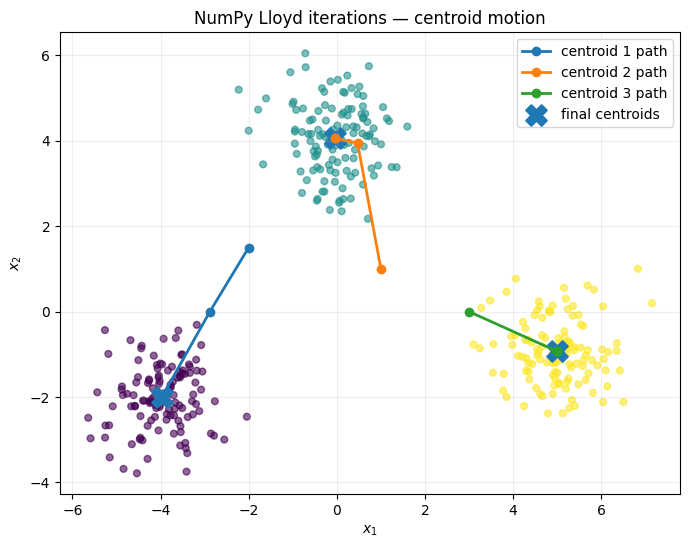

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(X_np[:, 0], X_np[:, 1], c=labels_np, s=24, alpha=0.60)

for k in range(K):
    plt.plot(
        path_np[:, k, 0],
        path_np[:, k, 1],
        marker="o",
        linewidth=2,
        label=f"centroid {k + 1} path",
    )

plt.scatter(
    M_np[:, 0],
    M_np[:, 1],
    marker="X",
    s=220,
    linewidths=1.5,
    label="final centroids",
)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("NumPy Lloyd iterations — centroid motion")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


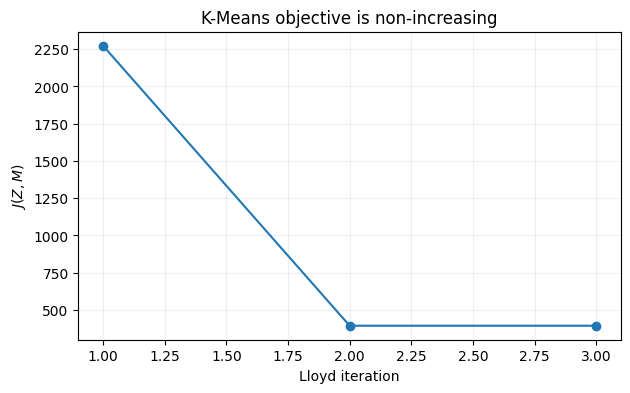

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(history_np) + 1), history_np, marker="o")
plt.xlabel("Lloyd iteration")
plt.ylabel("$J(Z,M)$")
plt.title("K-Means objective is non-increasing")
plt.grid(alpha=0.2)
plt.show()


# 12. SciPy — delegate numerical primitives after understanding them

Our NumPy implementation made the squared-distance matrix explicit. We can now replace that primitive with SciPy while keeping Lloyd's algorithm visible:

```python
scipy.spatial.distance.cdist(X, M, metric="sqeuclidean")
```

The intellectual ordering matters:

$$
\boxed{
\text{derive the operation}
\rightarrow
\text{implement it transparently}
\rightarrow
\text{delegate it to a mature scientific library}
}
$$


In [8]:
from scipy.spatial.distance import cdist


def assign_scipy(X, M):
    """Assignment step using SciPy's pairwise squared-distance primitive."""
    D = cdist(X, M, metric="sqeuclidean")
    labels = D.argmin(axis=1)
    Z = np.eye(len(M), dtype=X.dtype)[labels]
    return Z, labels


def kmeans_scipy_cdist(X, M0, max_iter=100):
    """Our Lloyd loop, but with SciPy providing the distance primitive."""
    M = M0.copy()
    previous_labels = None
    objective = []

    for _ in range(max_iter):
        Z, labels = assign_scipy(X, M)
        M = means_np(X, Z)
        objective.append(np.sum(Z * cdist(X, M, metric="sqeuclidean")))

        if previous_labels is not None and np.array_equal(labels, previous_labels):
            break

        previous_labels = labels.copy()

    return M, Z, labels, np.asarray(objective)


M_sp, Z_sp, labels_sp, history_sp = kmeans_scipy_cdist(X_np, M0)

print("SciPy-cdist centroids:")
print(M_sp)
print(f"\nIterations: {len(history_sp)}")
print(f"Final distortion: {history_sp[-1]:.6f}")


SciPy-cdist centroids:
[[-3.97268491 -2.00651271]
 [-0.04129587  4.05725   ]
 [ 4.98926392 -0.9262719 ]]

Iterations: 3
Final distortion: 394.380582


## 12.1 SciPy's complete K-Means implementation

Now move one abstraction level higher. `scipy.cluster.vq.kmeans2` performs the complete clustering procedure.

At this point the library call is no longer mysterious: we already know the conditional minimizations it is packaging.


In [9]:
from scipy.cluster.vq import kmeans2
from scipy.optimize import linear_sum_assignment

M_sp_lib, labels_sp_lib = kmeans2(
    X_np,
    M0.copy(),
    iter=100,
    minit="matrix",
    missing="raise",
)

D_sp_lib = cdist(X_np, M_sp_lib, metric="sqeuclidean")
J_sp_lib = D_sp_lib[np.arange(len(X_np)), labels_sp_lib].sum()

print("SciPy kmeans2 centroids:")
print(M_sp_lib)
print(f"\nFinal distortion: {J_sp_lib:.6f}")


SciPy kmeans2 centroids:
[[-3.97268491 -2.00651271]
 [-0.04129587  4.05725   ]
 [ 4.98926392 -0.9262719 ]]

Final distortion: 394.380582


## 12.2 Verify equivalence without assuming centroid label order

Cluster labels are arbitrary. One implementation may call a physical cluster “0” while another calls the same cluster “2”. Therefore we compare centroid *sets* by solving the small matching problem between the resulting centroids.


In [10]:
def match_centroids(A, B):
    """Return minimum-cost centroid matching and its distances."""
    cost = cdist(A, B, metric="euclidean")
    rows, cols = linear_sum_assignment(cost)
    return rows, cols, cost[rows, cols]

rows, cols, deviations = match_centroids(M_np, M_sp_lib)

print("NumPy ↔ SciPy centroid matching:")
for r, c, d in zip(rows, cols, deviations):
    print(f"  NumPy {r} ↔ SciPy {c}: distance = {d:.3e}")

print("\nmaximum centroid deviation:", deviations.max())
print("NumPy objective            :", history_np[-1])
print("SciPy kmeans2 objective    :", J_sp_lib)


NumPy ↔ SciPy centroid matching:
  NumPy 0 ↔ SciPy 0: distance = 0.000e+00
  NumPy 1 ↔ SciPy 1: distance = 0.000e+00
  NumPy 2 ↔ SciPy 2: distance = 0.000e+00

maximum centroid deviation: 0.0
NumPy objective            : 394.3805816027292
SciPy kmeans2 objective    : 394.38058160272897


# 13. PyTorch — the same matrix mathematics on CPU or CUDA

NumPy's standard `ndarray` execution model is CPU-based. PyTorch provides a closely related tensor vocabulary and can execute the same matrix expressions on a CUDA GPU.

The mathematics does not change:

$$
D
=
a\mathbf1_K^T
+
\mathbf1_Nb^T
-
2XM^T.
$$

The change is computational substrate:

$$
\boxed{
\text{NumPy / CPU}
\longrightarrow
\text{PyTorch tensor}
\longrightarrow
\text{CUDA when available}
}
$$

> **Colab:** select **Runtime → Change runtime type → GPU** to execute this section on a Colab GPU. Locally, the same code can use an NVIDIA CUDA-capable GPU when PyTorch is installed with CUDA support.


In [11]:
import torch
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA is unavailable here; the identical tensor code will run on CPU.")

X_t = torch.as_tensor(X_np, dtype=torch.float32, device=device)
M0_t = torch.as_tensor(M0, dtype=torch.float32, device=device)

print("X_t :", tuple(X_t.shape), X_t.device)
print("M0_t:", tuple(M0_t.shape), M0_t.device)


PyTorch version: 2.10.0+cpu
Device: cpu
CUDA is unavailable here; the identical tensor code will run on CPU.
X_t : (360, 2) cpu
M0_t: (3, 2) cpu


In [12]:
def sqdist_torch(X, M):
    """D = a 1^T + 1 b^T - 2 X M^T."""
    x2 = (X * X).sum(dim=1, keepdim=True)
    m2 = (M * M).sum(dim=1).unsqueeze(0)
    return (x2 + m2 - 2 * X @ M.T).clamp_min(0)


def assign_torch(X, M):
    """Nearest-centroid labels and one-hot Z."""
    labels = sqdist_torch(X, M).argmin(dim=1)
    Z = F.one_hot(labels, num_classes=len(M)).to(X.dtype)
    return Z, labels


def means_torch(X, Z):
    """M = diag(Z^T 1)^(-1) Z^T X, via row-wise division."""
    counts = Z.sum(dim=0)
    if torch.any(counts == 0):
        raise ValueError("K-Means produced an empty cluster.")
    return (Z.T @ X) / counts[:, None]


def distortion_torch(X, Z, M):
    """J(Z,M) = sum_ik z_ik ||x_i - mu_k||^2."""
    return (Z * sqdist_torch(X, M)).sum()


def kmeans_torch(X, M0, max_iter=100):
    """Lloyd's algorithm using PyTorch tensors on the selected device."""
    M = M0.clone()
    previous_labels = None
    objective = []

    for _ in range(max_iter):
        Z, labels = assign_torch(X, M)
        M = means_torch(X, Z)
        objective.append(distortion_torch(X, Z, M).detach())

        if previous_labels is not None and torch.equal(labels, previous_labels):
            break

        previous_labels = labels.clone()

    return M, Z, labels, torch.stack(objective)


In [13]:
M_t, Z_t, labels_t, history_t = kmeans_torch(X_t, M0_t)

M_t_np = M_t.detach().cpu().numpy()
labels_t_np = labels_t.detach().cpu().numpy()
history_t_np = history_t.detach().cpu().numpy()

print("PyTorch centroids:")
print(M_t_np)
print(f"\nIterations: {len(history_t_np)}")
print(f"Final distortion: {history_t_np[-1]:.6f}")


PyTorch centroids:
[[-3.9726844  -2.0065122 ]
 [-0.04129588  4.0572495 ]
 [ 4.989264   -0.926272  ]]

Iterations: 3
Final distortion: 394.380402


## 13.1 Visualize the PyTorch solution

The clustering computation stays in tensor memory on the selected device. Matplotlib expects CPU-accessible NumPy arrays, so visualization crosses the device boundary **once, after the computation**:

$$
\boxed{
\text{tensor on device}
\rightarrow
\text{CPU tensor}
\rightarrow
\text{NumPy array}
\rightarrow
\text{Matplotlib}
}
$$

implemented by

```python
tensor.detach().cpu().numpy()
```

Avoid moving arrays back and forth inside the Lloyd loop; repeated device synchronization and transfer would undermine GPU execution.


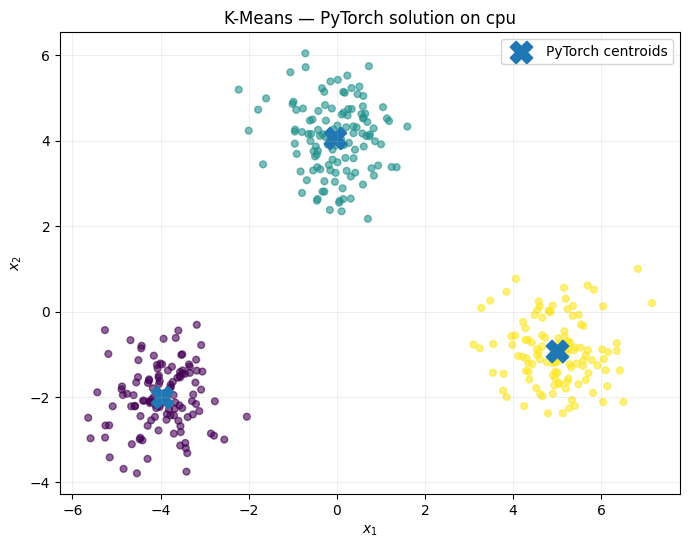

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(X_np[:, 0], X_np[:, 1], c=labels_t_np, s=24, alpha=0.60)
plt.scatter(
    M_t_np[:, 0],
    M_t_np[:, 1],
    marker="X",
    s=240,
    linewidths=1.5,
    label="PyTorch centroids",
)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title(f"K-Means — PyTorch solution on {device}")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


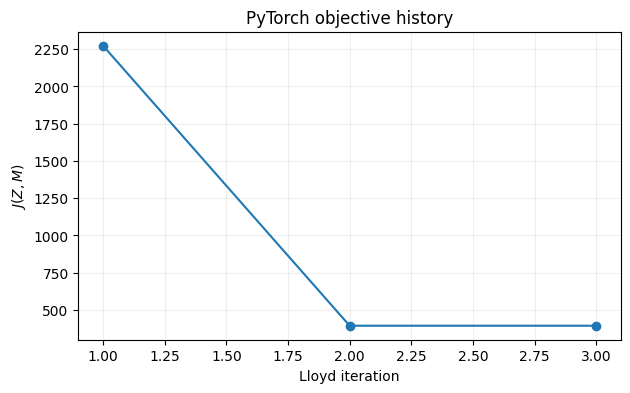

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(history_t_np) + 1), history_t_np, marker="o")
plt.xlabel("Lloyd iteration")
plt.ylabel("$J(Z,M)$")
plt.title("PyTorch objective history")
plt.grid(alpha=0.2)
plt.show()


## 13.2 Verify PyTorch against NumPy

PyTorch uses `float32` here, while NumPy/SciPy use `float64`, so bit-for-bit equality is neither required nor expected.

The relevant invariant is:

$$
\boxed{
\text{same mathematical algorithm}
\rightarrow
\text{same clustering solution within floating-point tolerance}
}
$$


In [16]:
rows_t, cols_t, deviations_t = match_centroids(M_np, M_t_np)

print("NumPy ↔ PyTorch centroid matching:")
for r, c, d in zip(rows_t, cols_t, deviations_t):
    print(f"  NumPy {r} ↔ PyTorch {c}: distance = {d:.3e}")

print("\nmaximum centroid deviation:", deviations_t.max())
print("NumPy objective           :", history_np[-1])
print("PyTorch objective         :", float(history_t_np[-1]))


NumPy ↔ PyTorch centroid matching:
  NumPy 0 ↔ PyTorch 0: distance = 7.556e-07
  NumPy 1 ↔ PyTorch 1: distance = 4.520e-07
  NumPy 2 ↔ PyTorch 2: distance = 1.238e-07

maximum centroid deviation: 7.556008242432419e-07
NumPy objective           : 394.3805816027292
PyTorch objective         : 394.3804016113281


# 14. Hardware-aware optimization — eliminate the dense one-hot matrix

The matrix formulation

$$
Z^TX
$$

is ideal for understanding the mathematics. But $Z\in\mathbb R^{N\times K}$ is mostly zeros: each row contains only one non-zero entry.

For large $N$ and $K$, we can keep only the integer labels and accumulate observations directly into their cluster sums.

In PyTorch, `index_add_` implements the operation that $Z^TX$ was expressing:

$$
\boxed{
Z^TX
\quad\longrightarrow\quad
\text{indexed accumulation by cluster label}
}
$$

This is an implementation optimization, not a different algorithm.


In [17]:
def means_torch_indexed(X, labels, K):
    """Cluster means without explicitly materializing one-hot Z."""
    sums = torch.zeros((K, X.shape[1]), dtype=X.dtype, device=X.device)
    sums.index_add_(0, labels, X)

    counts = torch.bincount(labels, minlength=K).to(X.dtype)
    if torch.any(counts == 0):
        raise ValueError("K-Means produced an empty cluster.")

    return sums / counts[:, None]


M_indexed = means_torch_indexed(X_t, labels_t, K)
print("max |matrix means - indexed means| =",
      (M_indexed - means_torch(X_t, Z_t)).abs().max().item())


max |matrix means - indexed means| = 0.0


# 15. Numerical and structural failure modes

### 🟢 Exact mathematical facts

- For fixed $M$, the assignment update is an exact conditional minimizer.
- For fixed non-empty $Z$, the centroid update is the unique conditional minimizer.
- The objective cannot increase after either exact Lloyd update.

### 🟡 Numerical considerations

The expanded distance identity

$$
\|x_i-\mu_k\|^2
=
\|x_i\|^2+\|\mu_k\|^2-2x_i^T\mu_k
$$

can produce tiny negative values in floating-point arithmetic through cancellation. The implementations therefore clamp values to zero before interpreting them as squared distances.

### 🔴 Modeling failure modes

K-Means can be a poor structural model when:

- clusters are strongly non-spherical;
- cluster densities differ substantially;
- feature scales are incomparable;
- outliers dominate squared distance;
- the desired groups are connected by curved manifolds;
- $K$ is badly chosen.

A mathematically correct optimization can still be the wrong model for the geometry of the data.


# 16. Final compression

K-Means begins with one objective:

$$
\boxed{
J(Z,M)=\sum_{i,k}z_{ik}\|x_i-\mu_k\|^2.
}
$$

Holding $M$ fixed gives

$$
\boxed{
c_i=\arg\min_k\|x_i-\mu_k\|^2.
}
$$

Holding $Z$ fixed gives

$$
\boxed{
\mu_k
=
\frac{\sum_i z_{ik}x_i}{\sum_i z_{ik}}.
}
$$

All centroids simultaneously:

$$
\boxed{
M=\operatorname{diag}(Z^T\mathbf1_N)^{-1}Z^TX.
}
$$

All pairwise distances simultaneously:

$$
\boxed{
D=a\mathbf1_K^T+\mathbf1_Nb^T-2XM^T.
}
$$

The algorithm is simply

```python
Z, labels = assign(X, M)
M = means(X, Z)
```

repeated until the assignments stabilize.

The implementation ladder is now transparent:

$$
\boxed{
\text{derivation}
\rightarrow
\text{NumPy executable mathematics}
\rightarrow
\text{SciPy scientific abstraction}
\rightarrow
\text{PyTorch / CUDA}
}
$$

The representations change. The underlying mathematics does not.


# 17. References and next directions

Foundational and canonical directions for further study:

- S. Lloyd, **Least Squares Quantization in PCM**.
- J. MacQueen, **Some Methods for Classification and Analysis of Multivariate Observations**.
- D. Pollard, **Strong Consistency of K-Means Clustering**.
- J. A. Hartigan and M. A. Wong, **Algorithm AS 136: A K-Means Clustering Algorithm**.
- D. Arthur and S. Vassilvitskii, **k-means++: The Advantages of Careful Seeding**.
- NumPy, SciPy, and PyTorch official numerical documentation.

Natural extensions are K-Means++, mini-batch K-Means, Gaussian mixture models, and the relationship between Euclidean K-Means and hard-EM-style alternating optimization.
